In the Chapter 5 Jupyter notebook. The regulation techniques used are L2 regularization, L1 regularization, L1-L2 regularization, and Dropout.

In [28]:
 import numpy as np
 import tensorflow as tf
 import matplotlib.pyplot as plt
 from tensorflow.keras.datasets import mnist
 from tensorflow import keras
 from tensorflow.keras import layers, regularizers
 from sklearn.model_selection import train_test_split

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255



In [29]:
def createMixedImages(label1, label2, new_label, num_train=6000, num_test=1000):
  images1_train = train_images[train_labels == label1]
  images2_train = train_images[train_labels == label2]
  images1_test = test_images[test_labels == label1]
  images2_test = test_images[test_labels == label2]

  num_train = min(len(images1_train), len(images2_train), num_train)
  num_test = min(len(images1_test), len(images2_test), num_test)

  mixed_train = (images1_train[:num_train] + images2_train[:num_train]) / 2
  mixed_test = (images1_test[:num_test] + images2_test[:num_test]) / 2

  labels_train = np.full((num_train,), new_label)
  labels_test = np.full((num_test,), new_label)

  return mixed_train, labels_train, mixed_test, labels_test

In [30]:
new_train_images, new_train_labels = [], []
new_test_images, new_test_labels = [], []

pairs = [(0,1), (2,3), (4,5), (6,7), (8,9)]
for new_label, (label1, label2) in enumerate(pairs):
  complete_train_images, complete_train_labels, complete_test_images, complete_test_labels = createMixedImages(label1, label2, new_label)
  new_train_images.append(complete_train_images)
  new_train_labels.append(complete_train_labels)
  new_test_images.append(complete_test_images)
  new_test_labels.append(complete_test_labels)

images_train = np.concatenate(new_train_images)
labels_train = np.concatenate(new_train_labels)
images_test = np.concatenate(new_test_images)
labels_test = np.concatenate(new_test_labels)

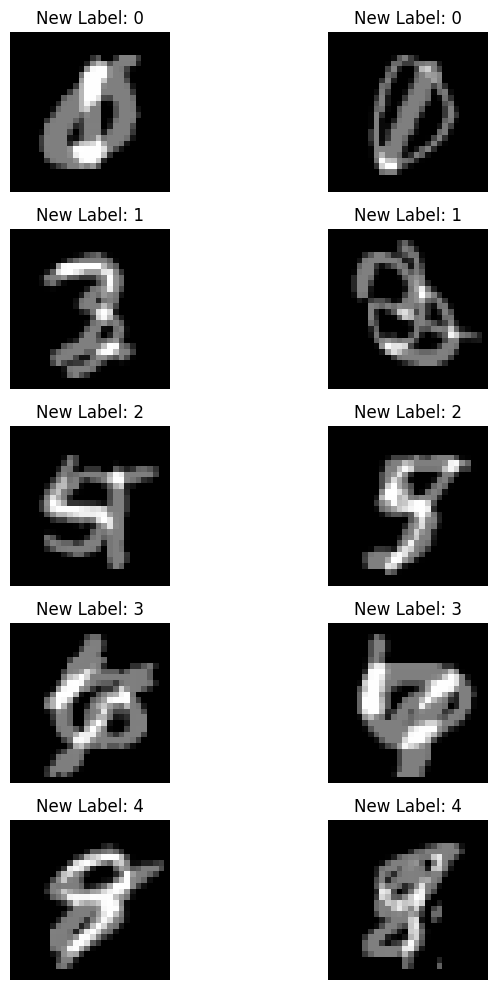

In [31]:
fig, axes = plt.subplots(5, 2, figsize=(8, 10))

for new_label in range(5):
    indices = np.where(labels_train == new_label)[0]
    chosen_indices = np.random.choice(indices, 2, replace=False)

    for j, idx in enumerate(chosen_indices):
        image = images_train[idx].reshape(28, 28)
        axes[new_label, j].imshow(image, cmap="gray")
        axes[new_label, j].set_title(f"New Label: {new_label}")
        axes[new_label, j].axis("off")

plt.tight_layout()
plt.show()

labels_train = tf.keras.utils.to_categorical(labels_train, num_classes=5)
labels_test = tf.keras.utils.to_categorical(labels_test, num_classes=5)

In [35]:
x_train, x_val, y_train, y_val = train_test_split(images_train, labels_train, test_size=0.2)

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,), kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')  # Output layer for 5 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=30, batch_size=256,
                    validation_data=(x_val, y_val))

test_loss, test_accuracy = model.evaluate(images_test, labels_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8267 - loss: 1.2590 - val_accuracy: 0.9596 - val_loss: 0.5504
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9568 - loss: 0.5036 - val_accuracy: 0.9629 - val_loss: 0.3977
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9682 - loss: 0.3576 - val_accuracy: 0.9635 - val_loss: 0.3120
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9711 - loss: 0.2773 - val_accuracy: 0.9702 - val_loss: 0.2529
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9736 - loss: 0.2303 - val_accuracy: 0.9646 - val_loss: 0.2413
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9743 - loss: 0.2038 - val_accuracy: 0.9721 - val_loss: 0.2012
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9787 - loss: 0.1771 - val_accuracy: 0.9740 - val_loss: 0.1882
Epoch 8/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9820 - loss: 0.1579 - val_accuracy: 0.9733 - v

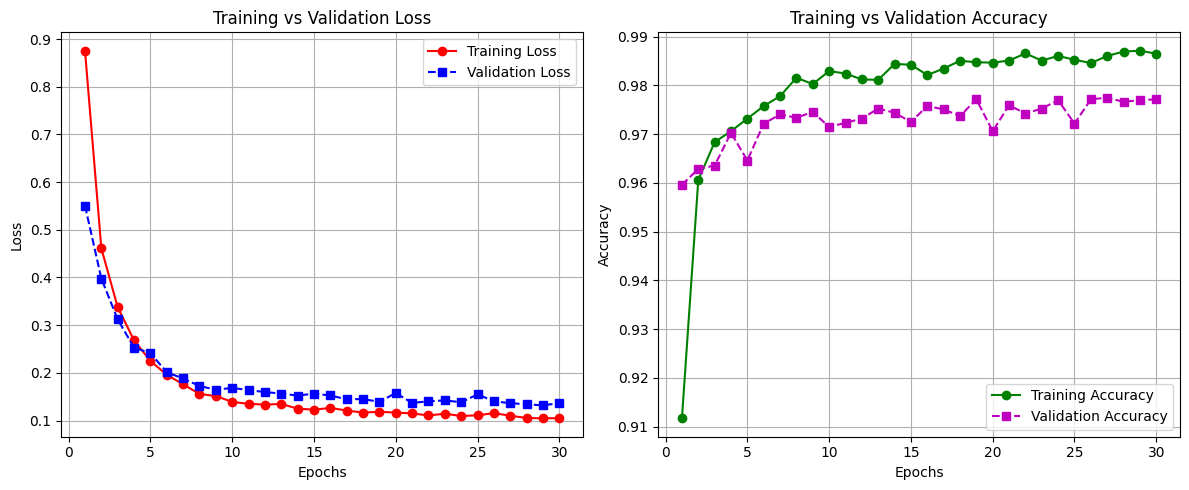

In [38]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

epochs = range(1, len(train_loss) + 1)  # Automatically adjust based on training

plt.figure(figsize=(12, 5))

# Plot Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, "r-", marker='o', label="Training Loss")
plt.plot(epochs, val_loss, "b--", marker='s', label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, "g-", marker='o', label="Training Accuracy")
plt.plot(epochs, val_acc, "m--", marker='s', label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()  # Adjust layout for readability
plt.show()

I used the regularization techniques from the start so I did not see any overfitting. And, since I had enough epochs run, and I did not have too small of a learning curve, I never ran into underfitting. I will say that based on the last homework the only reason that I did not run into overfitting was because I used L2 and dropout regularization. They help tremendously in keeping the model from overfitting.